# Hamiltonian Dynamics and Symplectic Integrators

Hamiltonian particle systems are a core model for mechanics, molecular dynamics, and statistical physics.
For a state $(q,p)$ with position $q\in\mathbb{R}^{2N}$ and momentum $p\in\mathbb{R}^{2N}$, the dynamics is
$$
\dot q = \nabla_p H(q,p), \qquad \dot p = -\nabla_q H(q,p).
$$
The key numerical question is not only short-term accuracy, but also long-term geometric fidelity:
does the scheme preserve invariants (especially energy) and qualitative trajectories?

This notebook studies an $N$-body system in a periodic square, with random initial positions and velocities.
We compare:
- explicit Euler (simple but not structure-preserving),
- velocity-Verlet / leapfrog (symplectic second-order method).

The goal is to illustrate why symplectic schemes are preferred for Hamiltonian simulations.


## Environment and Model Setup

We define a periodic square domain of side length $L$, random initial conditions, and a smooth bounded pair potential:
$$
U(r)=\varepsilon \exp\!\left(-\frac{r^2}{2\sigma^2}\right).
$$
With the minimum-image convention for periodic boundaries, pair distances stay consistent on the torus.
The associated force is
$$
F_{ij} = -\nabla_{q_i}U(\|q_i-q_j\|)=\frac{\varepsilon}{\sigma^2}\exp\!\left(-\frac{r_{ij}^2}{2\sigma^2}\right)(q_i-q_j).
$$


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("python/hamiltonian-symplectic")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(4)

N = 36               # number of particles
L = 1.0              # periodic box size
mass = 1.0
eps = 0.012          # interaction strength
sigma = 0.11         # interaction width
dt = 0.006           # integration step
T = 4.8              # total simulated time
n_steps = int(T / dt)

# Random initial conditions: centered speeds with moderate norm.
q0 = rng.uniform(0.0, L, size=(N, 2))
v0 = rng.normal(0.0, 1.0, size=(N, 2))
v0 -= v0.mean(axis=0, keepdims=True)
speed_scale = 0.22 / np.sqrt((v0**2).sum(axis=1).mean())
v0 *= speed_scale

expected_crossing_time = L / np.mean(np.linalg.norm(v0, axis=1))
print(f"dt={dt:.4f}, steps={n_steps}, mean speed={np.mean(np.linalg.norm(v0, axis=1)):.3f}, "
      f"crossing time~{expected_crossing_time:.2f}, simulated time={T:.2f}")


dt=0.0060, steps=800, mean speed=0.197, crossing time~5.07, simulated time=4.80


## Force, Energy, and Integrators

For periodic boundaries we wrap positions with $q\mapsto q \bmod L$, and compute pair displacements with minimum image:
$$
\Delta q = q_i-q_j - L\cdot\mathrm{round}\!\left(\frac{q_i-q_j}{L}\right).
$$
Total energy is
$$
H(q,p)=\sum_i \frac{\|p_i\|^2}{2m} + \sum_{i<j} U(\|q_i-q_j\|).
$$
We implement explicit Euler and velocity-Verlet using the same initial state.


In [2]:
def minimum_image(dq, box_size):
    return dq - box_size * np.round(dq / box_size)


def accel_and_potential(q):
    a = np.zeros_like(q)
    U = 0.0
    for i in range(N - 1):
        dq = q[i] - q[i + 1 :]
        dq = minimum_image(dq, L)
        r2 = np.sum(dq * dq, axis=1)
        w = np.exp(-0.5 * r2 / (sigma**2))
        U += np.sum(eps * w)
        f = (eps / (sigma**2)) * w[:, None] * dq
        a[i] += np.sum(f, axis=0) / mass
        a[i + 1 :] -= f / mass
    return a, U


def total_energy(q, v):
    _, U = accel_and_potential(q)
    K = 0.5 * mass * np.sum(v * v)
    return K + U


def integrate_euler(q_init, v_init):
    q = q_init.copy()
    v = v_init.copy()
    traj = np.zeros((n_steps + 1, N, 2))
    E = np.zeros(n_steps + 1)
    traj[0] = q
    E[0] = total_energy(q, v)
    for k in range(n_steps):
        a, _ = accel_and_potential(q)
        v = v + dt * a
        q = (q + dt * v) % L
        traj[k + 1] = q
        E[k + 1] = total_energy(q, v)
    return traj, E


def integrate_verlet(q_init, v_init):
    q = q_init.copy()
    v = v_init.copy()
    a, _ = accel_and_potential(q)
    traj = np.zeros((n_steps + 1, N, 2))
    E = np.zeros(n_steps + 1)
    traj[0] = q
    E[0] = total_energy(q, v)
    for k in range(n_steps):
        v_half = v + 0.5 * dt * a
        q = (q + dt * v_half) % L
        a_new, _ = accel_and_potential(q)
        v = v_half + 0.5 * dt * a_new
        a = a_new
        traj[k + 1] = q
        E[k + 1] = total_energy(q, v)
    return traj, E


## Numerical Comparison and Diagnostics

We now simulate both schemes and compare:
- wrapped trajectories of a subset of particles,
- relative energy drift
$$
\frac{H(t)-H(0)}{|H(0)|+\eta}.
$$
A symplectic method should exhibit markedly better long-time energy behavior.


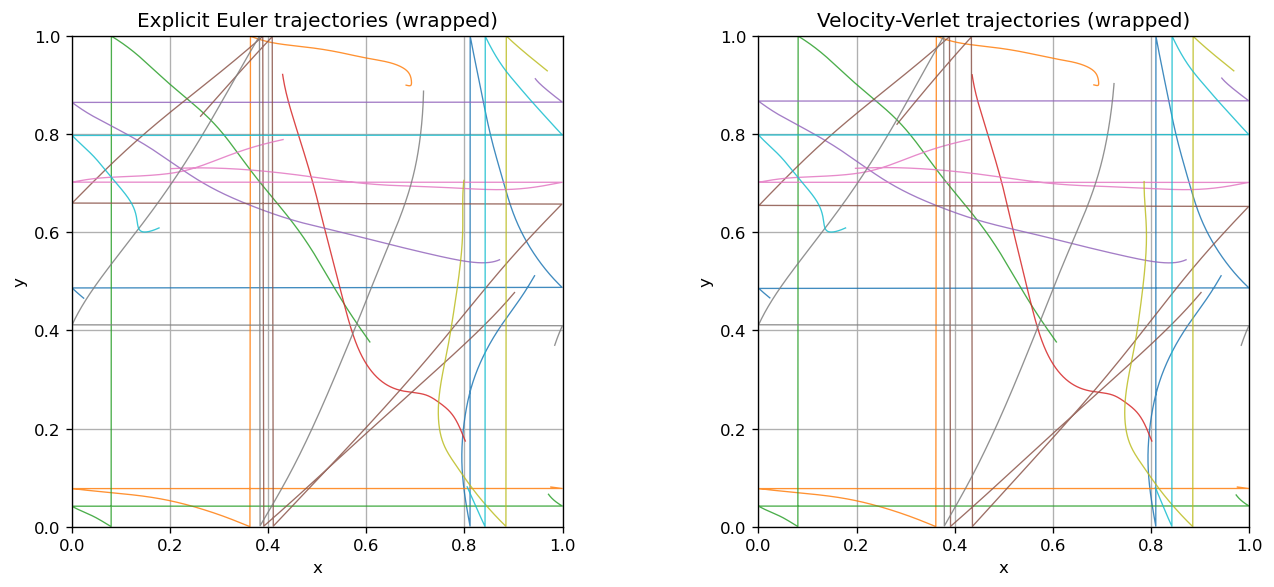

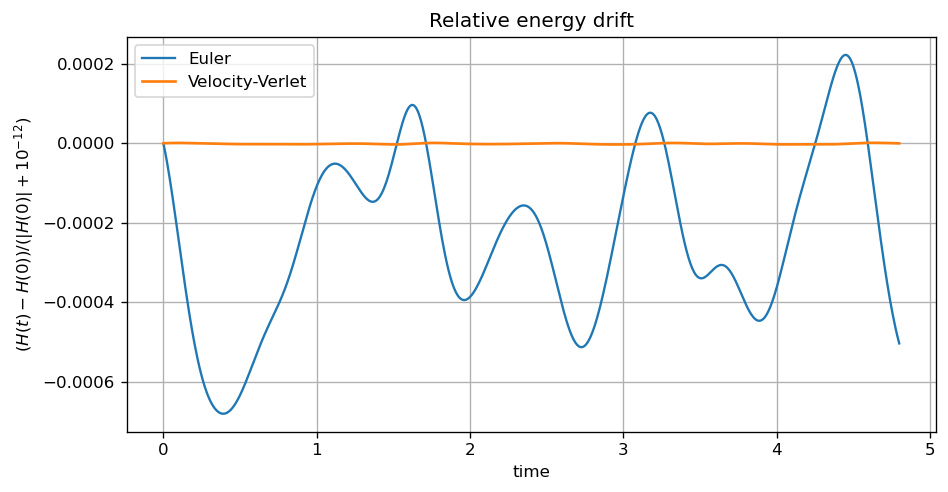

In [3]:
traj_e, E_e = integrate_euler(q0, v0)
traj_v, E_v = integrate_verlet(q0, v0)
t = dt * np.arange(n_steps + 1)

rel_e = (E_e - E_e[0]) / (abs(E_e[0]) + 1e-12)
rel_v = (E_v - E_v[0]) / (abs(E_v[0]) + 1e-12)

sel = np.arange(min(10, N))
fig, axes = plt.subplots(1, 2, figsize=(11.6, 5.0))

for i in sel:
    axes[0].plot(traj_e[:, i, 0], traj_e[:, i, 1], lw=0.8, alpha=0.85)
axes[0].set_title("Explicit Euler trajectories (wrapped)")
axes[0].set_xlim(0, L); axes[0].set_ylim(0, L)
axes[0].set_aspect("equal")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")

for i in sel:
    axes[1].plot(traj_v[:, i, 0], traj_v[:, i, 1], lw=0.8, alpha=0.85)
axes[1].set_title("Velocity-Verlet trajectories (wrapped)")
axes[1].set_xlim(0, L); axes[1].set_ylim(0, L)
axes[1].set_aspect("equal")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.plot(t, rel_e, lw=1.4, label="Euler")
ax.plot(t, rel_v, lw=1.6, label="Velocity-Verlet")
ax.set_title("Relative energy drift")
ax.set_xlabel("time")
ax.set_ylabel(r"$(H(t)-H(0))/(|H(0)|+10^{-12})$")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- E. Hairer, C. Lubich, G. Wanner, *Geometric Numerical Integration*, Springer, 2006.
- B. Leimkuhler, S. Reich, *Simulating Hamiltonian Dynamics*, Cambridge Univ. Press, 2004.
- M. P. Allen, D. J. Tildesley, *Computer Simulation of Liquids*, Oxford Univ. Press, 2017.
